# Proper Orthogonal Decomposition

This section demonstrates the implementation of proper orthogonal decomposition (POD) models. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section.

POD is a linear dimensionality reduction method that projects high-dimensional data, $x\in \mathbb{R}^n$, to a low-dimensional representation, $z\in \mathbb{R}^m$, where $m << n$. The fact that POD is a linear dimensionality reduction method means that it is only able to capture the linear trends and features of the data but cannot capture nonlinear features in the data such as discontinuities. In engineering settings, POD can be useful in modeling high-dimensional outputs from an engineering simulation or creating a low-dimensional projection of the input variables to better facilitate the process of surrogate modeling.

The main steps of performing POD are given below. For this explaination, consider that $X \in \mathbb{R}^{n\times p}$, is a matrix where each column of the matrix represents the high-dimensional data of the system. For example, this could be the pressure field output from a fluids simulation or the stress field output from a finite element simulation. There are a total of $p$ instances of the high-dimensional data. Consider this to be the outputs for $p$ different sampling points generated from a design of experiments. 

- **Perform singular value decomposition (SVD) on the high-dimensional data:** SVD is used to decompose the matrix $X$ into three separate matrices as follows:
$$X = U\Sigma V^T$$
where elements of $U \in \mathbb{R}^{n \times n}$ are called the left singular vectors and contain the eigenvectors of $XX^T$, elements of $V \in \mathbb{R}^{m \times m}$ are called the right singular vectors and contain the eignevectors of $X^TX$, and $\Sigma$ is a diagonal matrix containing the singular values of the matrix. The columns of $U$ form the POD modes of the matrix $X$. 

- **Truncate the columns of $U$ to obtain the POD modes:** After obtaining the SVD of the matrix, the columns of $U$ must be truncated since the full matrix $X$ can be represented effectively using only a few POD modes. The truncation involves calculating the relative information criterion (RIC) and using the number of modes that can meet the threshold of RIC that is set by the user. 

$$\text{RIC} = $$




In [16]:
import torch
from scimlstudio.models import POD
import matplotlib.pyplot as plt
from pyDOE3 import lhs

# defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float32
}

## Environment Model Function

The use of POD will be demonstrated using the Environment Model Function (EMF) that can be described as follows:



In [17]:
# defining the grid for the function
s_grid = torch.linspace(0.0, 2.50, 32, **args)
t_grid = torch.linspace(15.0, 60.0, 32, **args)
Sgrid, Tgrid = torch.meshgrid(s_grid, t_grid)

def env_model_function(x: torch.Tensor) -> torch.Tensor:
    """
        Parameters
        ----------
        x: torch.Tensor
            2D tensor array with the inputs to the function

        Returns
        -------
        y: torch.Tensor
            Values of the EMF evaluated for the given inputs

    """

    # extracting values of variables
    M = x[0]
    D = x[1]
    L = x[2]
    tau = x[3]

    first_term = (M/torch.sqrt(4 * torch.pi * D * Tgrid)) * torch.exp(-(Sgrid**2)/(4*D*Tgrid))
    second_term = (M/torch.sqrt(4 * torch.pi * D * (Tgrid - tau))) * torch.exp(-((Sgrid - L) ** 2)/(4*D*(Tgrid - tau)))
    second_term[torch.isnan(second_term)] = 0.0
    y = first_term + second_term

    return y

Let's create some training and testing data for the POD dimensionality reduction method. There are 25 training samples generated and 100 testing samples used. The EMF is evaluated on a 32 x 32 grid for (s,t) which means that there are a total of 1024 values to model for the EMF over this grid. Since there are 4 input variables for the function, Latin hypercube sampling (LHS) is used to generate the training and testing data for the POD method. 

In [26]:
# defining the bounds
l_bounds = torch.tensor([7.0, 0.02, 0.01, 30.01], **args)
u_bounds = torch.tensor([13.0, 0.12, 3.0, 30.295], **args)

# training data generation
train_samples = torch.tensor(lhs(n=4, samples=1000, criterion='cm', iterations=1000), **args)
train_samples = l_bounds + (u_bounds - l_bounds) * train_samples
xtrain = torch.stack([env_model_function(x) for x in train_samples]) # this uses a 32x32 grid leading to a total of 1024 outputs
print(f"Shape of training data: {xtrain.shape}")

# testing data generation
test_samples = torch.tensor(lhs(n=4, samples=100, criterion='cm', iterations=1000), **args)
test_samples = l_bounds + (u_bounds - l_bounds) * test_samples
xtest = torch.stack([env_model_function(x) for x in test_samples])
print(f"Shape of testing data: {xtest.shape}")

Shape of training data: torch.Size([1000, 32, 32])
Shape of testing data: torch.Size([100, 32, 32])


Now, let's plot some examples of the EMF for different samples from the training data. Each output is now actually a field evaluated over a grid. So, we will plot contour plots for each sample in the training data. 

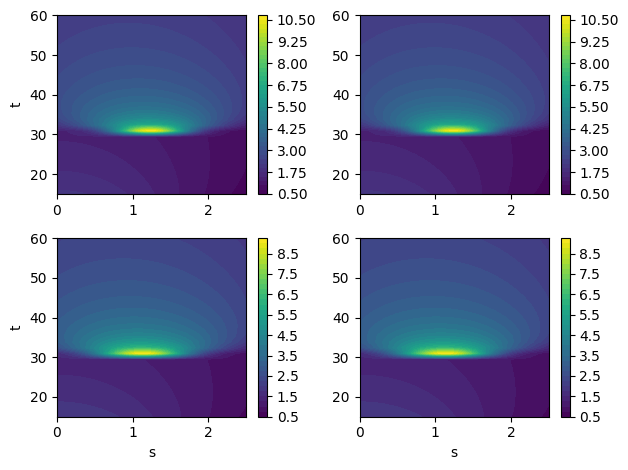

In [27]:
fig, ax = plt.subplots(2,2)

for i in range(2):
    for j in range(2):
        contour = ax[i,j].contourf(Sgrid, Tgrid, xtrain[i+3], levels = 40)
        if i == 1:
            ax[i,j].set_xlabel("s") 
        if j == 0:
            ax[i,j].set_ylabel("t")
        fig.colorbar(contour, ax=ax[i,j])

plt.tight_layout()

## Define the POD model



Number of modes to meet RIC value: 39


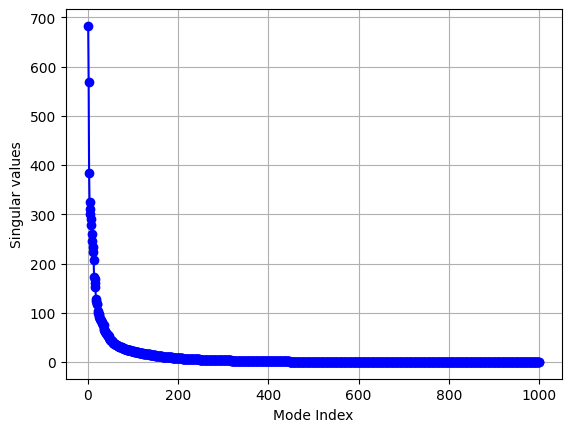

In [33]:
import numpy as np

# reshape the training data such that each column is the field and the number of columns 
# is the number of training samples
mean_snapshots = torch.mean(xtrain, axis = 0)
centre_snapshots = xtrain - mean_snapshots
pod = POD(s_train=centre_snapshots.reshape(-1, centre_snapshots.shape[0]), ric=0.95, snapshot_transform=None)
pod.fit()
print(f"Number of modes to meet RIC value: {pod.k}")

# plotting the singular values of the POD model
fig, ax = plt.subplots()
ax.plot(np.arange(1,xtrain.shape[0]+1), pod.S, 'bo-')
ax.set_ylabel('Singular values')
ax.set_xlabel('Mode Index')
ax.grid()

## Plotting the POD modes for the EMF

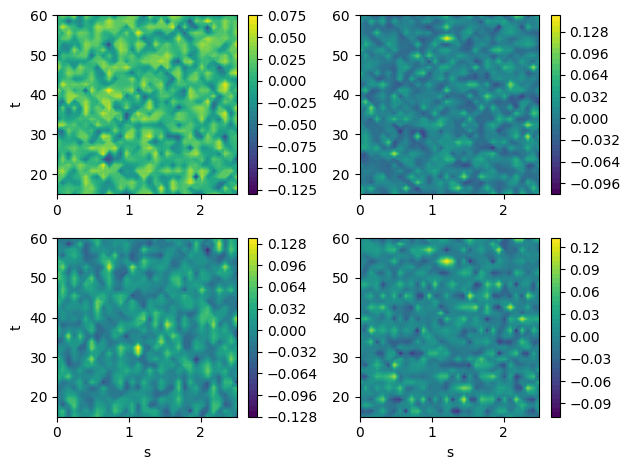

In [34]:
fig, ax = plt.subplots(2,2)
plotting_modes = [[pod.modes[:,0], pod.modes[:,1]], [pod.modes[:,2], pod.modes[:,3]]]

for i in range(2):
    for j in range(2):
        contour = ax[i,j].contourf(Sgrid, Tgrid, plotting_modes[i][j].reshape(32,32), levels = 40)
        if i == 1:
            ax[i,j].set_xlabel("s") 
        if j == 0:
            ax[i,j].set_ylabel("t")
        fig.colorbar(contour, ax=ax[i,j])

plt.tight_layout()

## Reconstructing the EMF using the POD modes

In [ ]:
# using the predict method to reconstruct the EMF
centre_test = xtest - mean_snapshots
predictions = pod.predict(centre_test.reshape(-1, centre_test.shape[0]))
predictions_reshaped = predictions.T.reshape([100,32,32]) + mean_snapshots

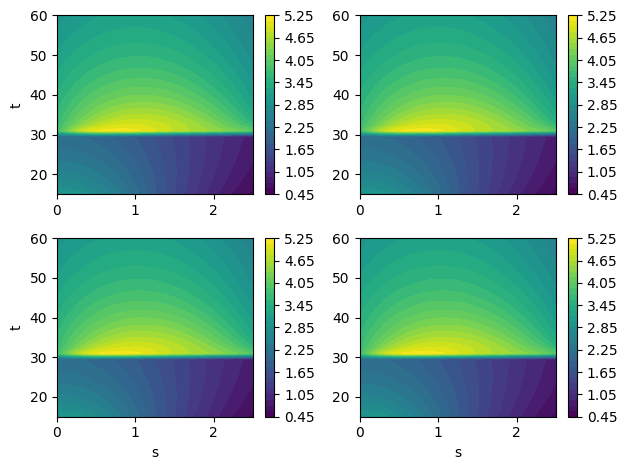

In [39]:
# plotting the reconstructions
fig, ax = plt.subplots(2,2)

for i in range(2):
    for j in range(2):
        contour = ax[i,j].contourf(Sgrid, Tgrid, mean_snapshots, levels = 40)
        if i == 1:
            ax[i,j].set_xlabel("s") 
        if j == 0:
            ax[i,j].set_ylabel("t")
        fig.colorbar(contour, ax=ax[i,j])

plt.tight_layout()